In [1]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))

from evaluation.multimodal_analysis import (
    load_comparison, plot_f1_comparison, print_summary_table,
    plot_per_class_accuracy, plot_confusion_matrix
)
from configs.fold_selection import MULTIMODAL_TEST_DIALOGUES


In [2]:
df = load_comparison(selected_dialogues=MULTIMODAL_TEST_DIALOGUES)
df


Building AFC Context: 100%|██████████| 1278/1278 [00:00<00:00, 4651.28it/s]


,dialogue_id,year,n_classes,n_samples,roberta_afc,wavlm_roberta_afc,wavlm_roberta_afc_focal
0,13_1988,1988,6,58,0.354870,0.465988,0.251852
1,22_1996,1996,5,62,0.351227,0.575186,0.261279
2,25_2000,2000,6,40,0.374717,0.430124,NaN
3,31_2004,2004,6,43,0.413943,0.564815,NaN
4,46_2020,2020,5,52,0.472149,0.475076,NaN


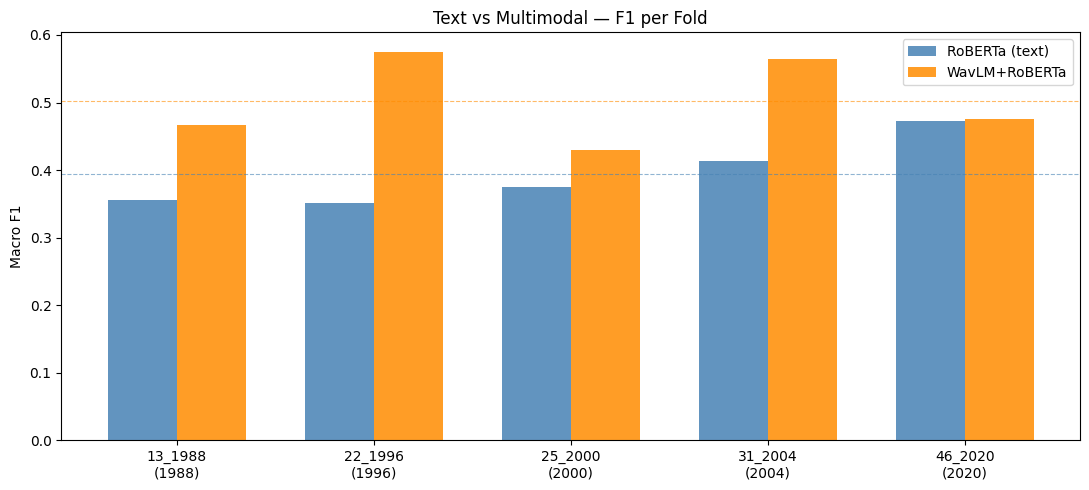


Model                      Mean F1      Std  Folds
RoBERTa (text)              0.3934   0.0506      5
WavLM+RoBERTa               0.5022   0.0642      5


In [3]:
plot_f1_comparison(df)
print_summary_table(df)


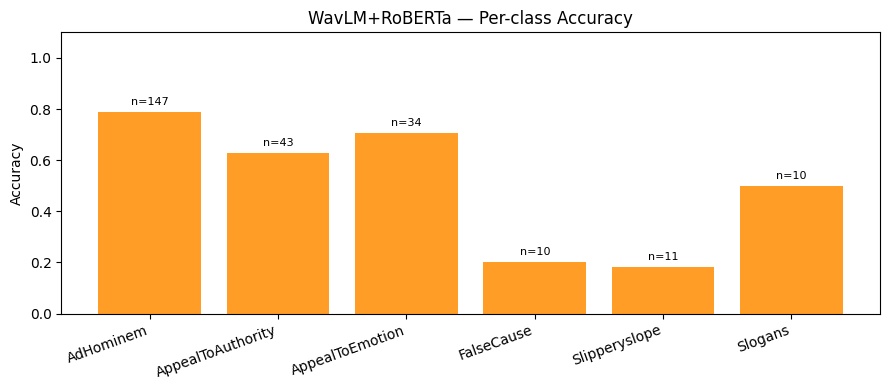

In [4]:
plot_per_class_accuracy(df)


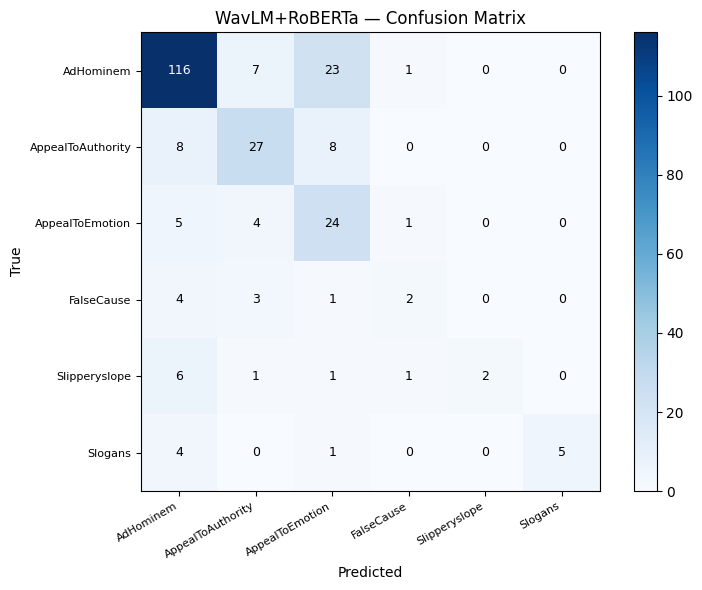

In [7]:
plot_confusion_matrix(df)


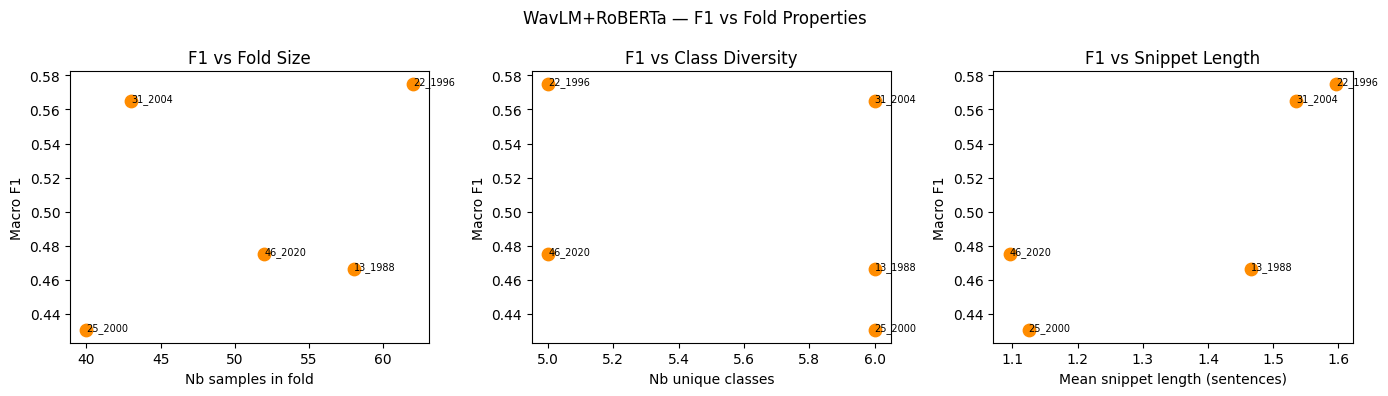

In [4]:
from evaluation.multimodal_analysis import plot_f1_vs_fold_properties
plot_f1_vs_fold_properties(df)


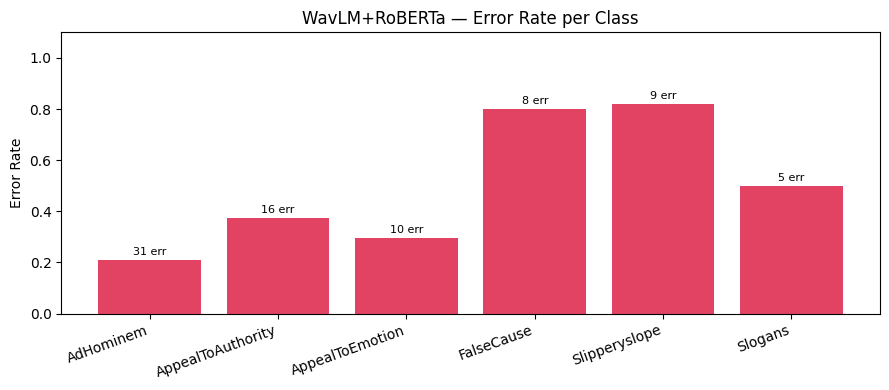

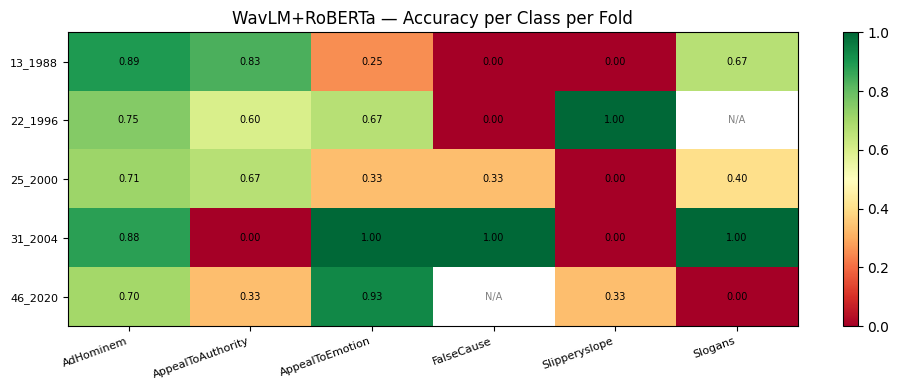

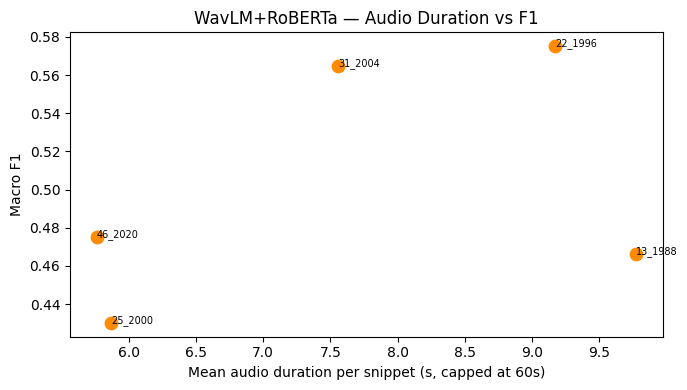

In [3]:
from evaluation.multimodal_analysis import (
    plot_error_distribution, plot_f1_per_class_per_fold, plot_audio_duration_vs_f1
)

plot_error_distribution(df)
plot_f1_per_class_per_fold(df)
plot_audio_duration_vs_f1(df)


## Audit check 

Loading Whisper 'medium'...
  [50/1278] mean WER so far: 0.277
  [100/1278] mean WER so far: 0.214
  [150/1278] mean WER so far: 0.208
  [200/1278] mean WER so far: 0.210
  [250/1278] mean WER so far: 0.228
  [300/1278] mean WER so far: 0.235
  [350/1278] mean WER so far: 0.246
  [400/1278] mean WER so far: 0.243
  [450/1278] mean WER so far: 0.240
  [500/1278] mean WER so far: 0.234
  [550/1278] mean WER so far: 0.226
  [600/1278] mean WER so far: 0.231
  [650/1278] mean WER so far: 0.234
  [700/1278] mean WER so far: 0.234
  [750/1278] mean WER so far: 0.240
  [800/1278] mean WER so far: 0.243
  [850/1278] mean WER so far: 0.237
  [900/1278] mean WER so far: 0.248
  [988/1278] mean WER so far: 0.280
  [1038/1278] mean WER so far: 0.286
  [1088/1278] mean WER so far: 0.290
  [1168/1278] mean WER so far: 0.317
  [1218/1278] mean WER so far: 0.319
  [1268/1278] mean WER so far: 0.318

Done. 1278 clips audited.
Mean WER : 0.3188
Median WER: 0.0625
WER > 0.5 : 228 clips

WHISPER AUDIT SUM

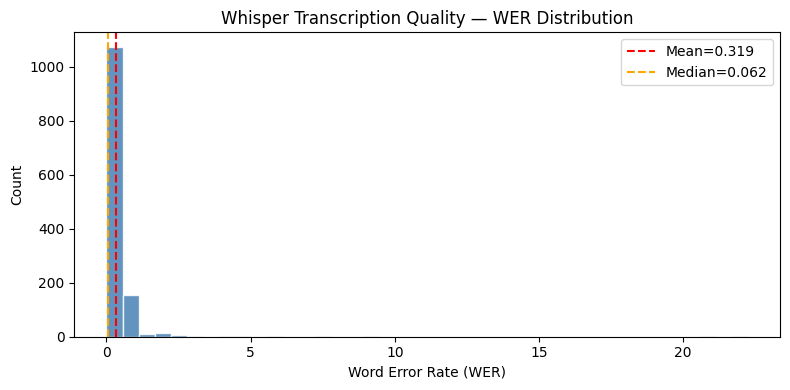

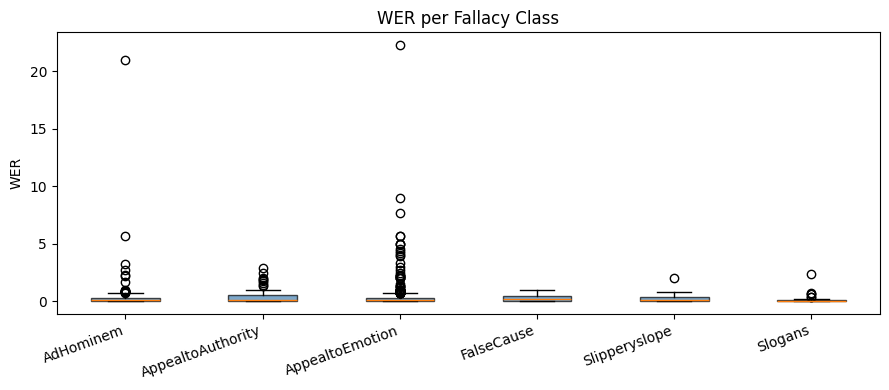


TOP 10 WORST TRANSCRIPTIONS (by WER)

[9_1980 | AppealtoEmotion | WER=22.250]
  REF    : It's a bully pulpit.
  WHISPER: when there's hopelessness at home, lack of work and so forth. But I believe that all of us together, and I believe the p

[44_2020 | AdHominem | WER=21.000]
  REF    : You can't even say the word law enforcement.
  WHISPER: I have Texas. I have Ohio. I have every — excuse me, Portland. The sheriff just came out today, and he said, I support P

[44_2020 | AppealtoEmotion | WER=9.000]
  REF    : This is going to be a fraud like you've never seen.
  WHISPER: This is going to be a fraud like you've never seen. The other thing, it's nice on November 3rd, you're watching and you 

[8_1980 | AppealtoEmotion | WER=7.667]
  REF    : We spoke a multitude of tongues.
  WHISPER: We came from a hundred different corners of the earth. We spoke a multitude of tongues, landed on this eastern shore, an

[9_1980 | AdHominem | WER=5.684]
  REF    : He wants to put all our eggs in one 

In [3]:
import sys
from pathlib import Path
ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src.data.whisper_audit import (
    run_whisper_audit,
    print_audit_summary,
    plot_wer_distribution,
    plot_wer_per_class,
    show_worst_transcriptions,
)

# Audit complet (medium = bon compromis vitesse/qualité, ~2-3 min)
audit_df = run_whisper_audit(model_name="medium")

# Résumé stats
print_audit_summary(audit_df)

# Plots
plot_wer_distribution(audit_df)
plot_wer_per_class(audit_df)

# Les pires transcriptions
show_worst_transcriptions(audit_df, n=10)


In [24]:
print("WER global :")
print(f"  Mean   : {audit_df['wer'].mean():.4f}")
print(f"  Median : {audit_df['wer'].median():.4f}")
print(f"  WER = 0     : {(audit_df['wer']==0).sum()} ({100*(audit_df['wer']==0).mean():.1f}%)")
print(f"  WER <= 0.1  : {(audit_df['wer']<=0.1).sum()} ({100*(audit_df['wer']<=0.1).mean():.1f}%)")
print(f"  WER > 0.5   : {(audit_df['wer']>0.5).sum()} ({100*(audit_df['wer']>0.5).mean():.1f}%)")
print()
print(f"{'Fallacy':<25} {'Mean WER':>9} {'Median':>9} {'N':>5}")
for cls, grp in audit_df.groupby('fallacy'):
    w = grp['wer'].dropna()
    print(f"{cls:<25} {w.mean():>9.4f} {w.median():>9.4f} {len(w):>5}")


WER global :
  Mean   : 0.3188
  Median : 0.0625
  WER = 0     : 486 (38.0%)
  WER <= 0.1  : 738 (57.7%)
  WER > 0.5   : 228 (17.8%)

Fallacy                    Mean WER    Median     N
AdHominem                    0.4419    0.0667   149
AppealtoAuthority            0.3134    0.1000   191
AppealtoEmotion              0.3132    0.0526   800
FalseCause                   0.2654    0.1507    56
Slipperyslope                0.2373    0.0690    46
Slogans                      0.1494    0.0000    36


In [ ]:
audit_df.to_csv("../results/whisper_audit.csv", index=False)
print("Saved.")


Saved.


In [12]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def _normalize(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    return re.sub(r"\s+", " ", text).strip()

def _best_match_score(ref, hyp):
    ref_words = _normalize(ref).split()
    hyp_words = _normalize(hyp).split()
    if not ref_words or not hyp_words:
        return 0.0
    n = len(ref_words)
    best = 0
    for start in range(max(1, len(hyp_words) - n + 1)):
        matches = sum(r == h for r, h in zip(ref_words, hyp_words[start:start + n]))
        best = max(best, matches / n)
    return best

audit_df = pd.read_csv("../results/whisper_audit.csv").fillna("")
audit_df["match_score"] = audit_df.apply(
    lambda r: _best_match_score(r["ref_text"], r["whisper_text"]), axis=1
)

def classify_clip(row):
    match = row["match_score"]
    wer   = row["wer"]
    if match >= 0.80 and wer <= 0.20:
        return "Good"
    elif match >= 0.80 and wer > 0.20:
        return "TooLong"
    elif match < 0.50 and wer <= 0.20:
        return "TooShort"
    else:
        return "BadAlignment"

audit_df["alignment_type"] = audit_df.apply(classify_clip, axis=1)

print(audit_df["alignment_type"].value_counts())
print(f"Total: {len(audit_df)} clips")

alignment_type
Good            659
BadAlignment    407
TooShort        135
TooLong          77
Name: count, dtype: int64
Total: 1278 clips


/tmp/ipykernel_1175091/3843069962.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1,1].boxplot(wer_data, labels=classes, patch_artist=True)


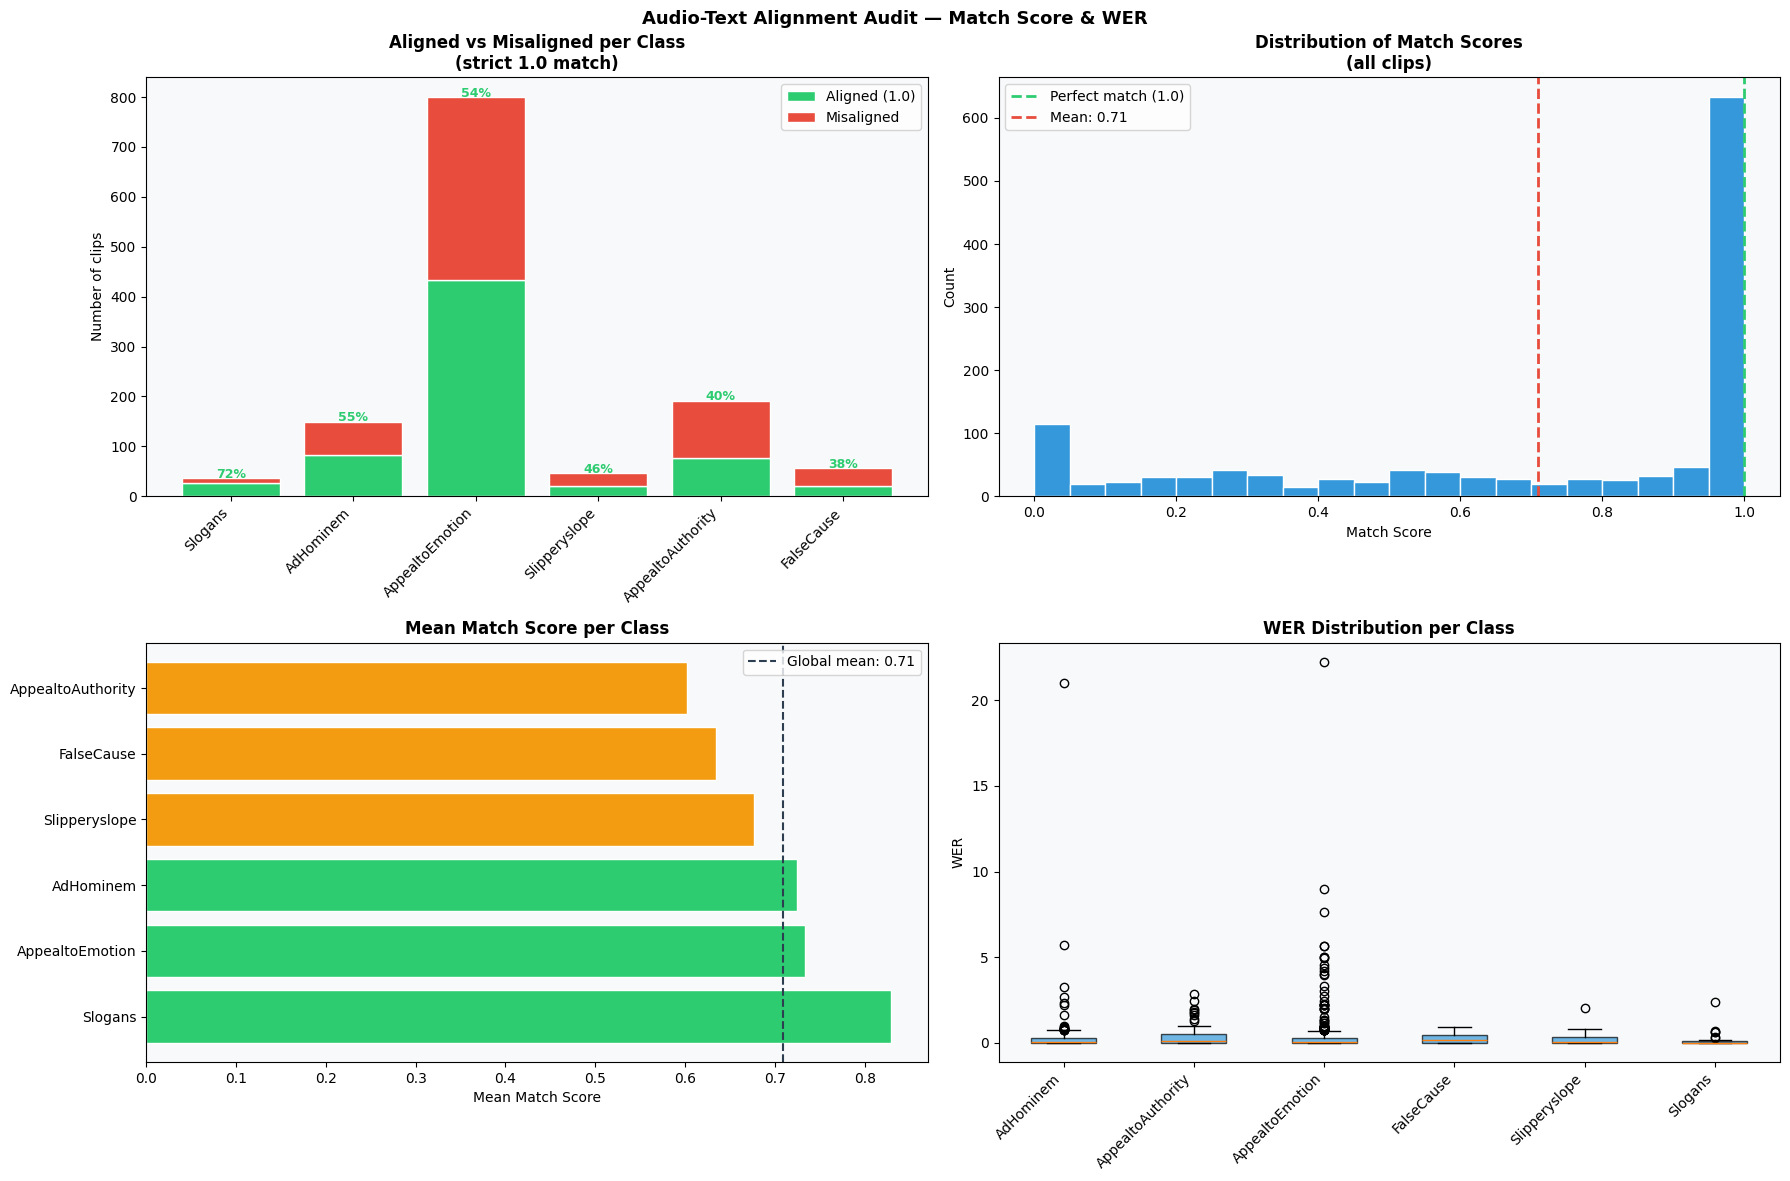


Global stats:
  Total clips  : 1278
  Aligned (1.0): 659 (51.6%)
  Mean score   : 0.709

Per class (match score + WER):
  AdHominem                 aligned= 82/149 (55%)  WER mean=0.442  median=0.067
  AppealtoAuthority         aligned= 76/191 (40%)  WER mean=0.313  median=0.100
  AppealtoEmotion           aligned=433/800 (54%)  WER mean=0.313  median=0.053
  FalseCause                aligned= 21/56 (38%)  WER mean=0.265  median=0.151
  Slipperyslope             aligned= 21/46 (46%)  WER mean=0.237  median=0.069
  Slogans                   aligned= 26/36 (72%)  WER mean=0.149  median=0.000


In [13]:
import matplotlib.pyplot as plt
import numpy as np

class_stats = []
for cls, grp in audit_df.groupby('fallacy'):
    n_total = len(grp)
    n_aligned = (grp['alignment_type'] == 'Good').sum()
    n_mis = n_total - n_aligned
    pct_aligned = 100 * n_aligned / n_total
    class_stats.append({
        'class': cls,
        'n_total': n_total,
        'n_aligned': n_aligned,
        'n_misaligned': n_mis,
        'pct_aligned': pct_aligned
    })

stats_df = pd.DataFrame(class_stats).sort_values('pct_aligned', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1 — Stacked bar aligned vs misaligned
x = np.arange(len(stats_df))
axes[0,0].bar(x, stats_df['n_aligned'], color='#2ecc71', label='Aligned (1.0)', edgecolor='white')
axes[0,0].bar(x, stats_df['n_misaligned'], bottom=stats_df['n_aligned'], color='#e74c3c', label='Misaligned', edgecolor='white')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(stats_df['class'], rotation=45, ha='right')
axes[0,0].set_ylabel('Number of clips')
axes[0,0].set_title('Aligned vs Misaligned per Class\n(strict 1.0 match)', fontweight='bold')
axes[0,0].legend()
axes[0,0].set_facecolor('#f8f9fa')
for i, row in stats_df.reset_index().iterrows():
    axes[0,0].text(i, row['n_total'] + 1, f"{row['pct_aligned']:.0f}%",
                   ha='center', fontsize=9, color='#2ecc71', fontweight='bold')

# Plot 2 — Distribution du match_score
axes[0,1].hist(audit_df['match_score'], bins=20, color='#3498db', edgecolor='white')
axes[0,1].axvline(x=1.0, color='#2ecc71', linestyle='--', linewidth=2, label='Perfect match (1.0)')
axes[0,1].axvline(x=audit_df['match_score'].mean(), color='#e74c3c', linestyle='--', linewidth=2,
                  label=f"Mean: {audit_df['match_score'].mean():.2f}")
axes[0,1].set_xlabel('Match Score')
axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Distribution of Match Scores\n(all clips)', fontweight='bold')
axes[0,1].legend()
axes[0,1].set_facecolor('#f8f9fa')

# Plot 3 — Match score moyen par classe
mean_scores = audit_df.groupby('fallacy')['match_score'].mean().sort_values(ascending=False)
colors = ['#2ecc71' if s > 0.7 else '#f39c12' if s > 0.5 else '#e74c3c' for s in mean_scores.values]
axes[1,0].barh(mean_scores.index, mean_scores.values, color=colors, edgecolor='white')
axes[1,0].axvline(x=audit_df['match_score'].mean(), color='#2c3e50', linestyle='--', linewidth=1.5,
                  label=f"Global mean: {audit_df['match_score'].mean():.2f}")
axes[1,0].set_xlabel('Mean Match Score')
axes[1,0].set_title('Mean Match Score per Class', fontweight='bold')
axes[1,0].legend()
axes[1,0].set_facecolor('#f8f9fa')

# Plot 4 — WER par classe (boxplot)
classes = sorted(audit_df['fallacy'].unique())
wer_data = [audit_df[audit_df['fallacy'] == c]['wer'].dropna().values for c in classes]
bp = axes[1,1].boxplot(wer_data, labels=classes, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#3498db')
    patch.set_alpha(0.7)
axes[1,1].set_ylabel('WER')
axes[1,1].set_title('WER Distribution per Class', fontweight='bold')
axes[1,1].set_facecolor('#f8f9fa')
plt.setp(axes[1,1].get_xticklabels(), rotation=45, ha='right')

fig.suptitle('Audio-Text Alignment Audit — Match Score & WER', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/alignment_audit_strict.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nGlobal stats:")
print(f"  Total clips  : {len(audit_df)}")
print(f"  Aligned (1.0): {(audit_df['alignment_type'] == 'Good').sum()} ({100*(audit_df['alignment_type'] == 'Good').mean():.1f}%)")
print(f"  Mean score   : {audit_df['match_score'].mean():.3f}")
print(f"\nPer class (match score + WER):")
for cls, grp in audit_df.groupby('fallacy'):
    w = grp['wer'].dropna()
    n_al = (grp['alignment_type'] == 'Good').sum()
    print(f"  {cls:<25} aligned={n_al:>3}/{len(grp)} ({100*n_al/len(grp):.0f}%)  WER mean={w.mean():.3f}  median={w.median():.3f}")


In [14]:
# Classer chaque clip dans un des 4 cas
def classify_case(row):
    ms = row['match_score']
    wer = row['wer']
    if ms == 1.0 and wer <= 0.1:
        return 'perfect'           # audio = texte exact
    elif ms < 1.0 and wer > 0.3 and row['whisper_len'] > row['ref_len'] * 1.3:
        return 'type1_longer'      # audio contient le texte + contexte
    elif ms <= 0.3 and wer > 0.5:
        return 'misaligned'        # audio dit autre chose
    elif ms == 0.0 and wer >= 1.0:
        return 'silent_noisy'      # clip silencieux / bruit
    else:
        return 'partial'           # entre les deux

audit_df['case'] = audit_df.apply(classify_case, axis=1)

print(audit_df['case'].value_counts())
print()

# Afficher N exemples par cas
N = 3
for case in ['perfect', 'type1_longer', 'misaligned', 'silent_noisy', 'partial']:
    subset = audit_df[audit_df['case'] == case]
    print(f"\n{'='*70}")
    print(f"CAS : {case.upper()}  ({len(subset)} clips)")
    print(f"{'='*70}")
    for _, row in subset.sample(min(N, len(subset)), random_state=42).iterrows():
        print(f"\n  [{row['dialogue_id']} | {row['fallacy']} | match={row['match_score']:.2f} | WER={row['wer']:.2f} | ref={row['ref_len']}w whisper={row['whisper_len']}w]")
        print(f"  REF    : {row['ref_text']}")
        print(f"  WHISPER: {row['whisper_text']}")



case
partial         657
perfect         504
misaligned      101
type1_longer     16
Name: count, dtype: int64


CAS : PERFECT  (504 clips)

  [29_2004 | AppealtoEmotion | match=1.00 | WER=0.00 | ref=6w whisper=6w]
  REF    : I disagree, strongly disagree with that.
  WHISPER: I disagree, strongly disagree with that.

  [36_2008 | AppealtoEmotion | match=1.00 | WER=0.00 | ref=13w whisper=13w]
  REF    : I think we all know America is going through tough times right now.
  WHISPER: I think we all know America is going through tough times right now.

  [46_2020 | AppealtoEmotion | match=1.00 | WER=0.00 | ref=13w whisper=13w]
  REF    : That's why so many people in my state were dying and getting cancer.
  WHISPER: That's why so many people in my state were dying and getting cancer.

CAS : TYPE1_LONGER  (16 clips)

  [10_1984 | AppealtoAuthority | match=0.85 | WER=1.79 | ref=39w whisper=109w]
  REF    : Everybody -- every economist, every businessman -- believes that. Every chairman of th

In [15]:
# Comparer les deux seuils
for wer_threshold in [0.2, 0.3, 0.5]:
    mask = (audit_df['match_score'] >= 0.80) & (audit_df['wer'] <= wer_threshold)
    print(f"WER <= {wer_threshold} + match >= 0.80 : "
          f"{mask.sum()} clips ({100*mask.mean():.1f}%)")
    
    # Par classe
    for cls, grp in audit_df.groupby('fallacy'):
        cls_mask = mask & (audit_df['fallacy'] == cls)
        print(f"  {cls:<25} {cls_mask.sum():>3} / {len(grp)} ({100*cls_mask.mean():.1f}%)")
    print()

WER <= 0.2 + match >= 0.80 : 659 clips (51.6%)
  AdHominem                  82 / 149 (6.4%)
  AppealtoAuthority          76 / 191 (5.9%)
  AppealtoEmotion           433 / 800 (33.9%)
  FalseCause                 21 / 56 (1.6%)
  Slipperyslope              21 / 46 (1.6%)
  Slogans                    26 / 36 (2.0%)

WER <= 0.3 + match >= 0.80 : 666 clips (52.1%)
  AdHominem                  82 / 149 (6.4%)
  AppealtoAuthority          76 / 191 (5.9%)
  AppealtoEmotion           439 / 800 (34.4%)
  FalseCause                 21 / 56 (1.6%)
  Slipperyslope              22 / 46 (1.7%)
  Slogans                    26 / 36 (2.0%)

WER <= 0.5 + match >= 0.80 : 678 clips (53.1%)
  AdHominem                  82 / 149 (6.4%)
  AppealtoAuthority          79 / 191 (6.2%)
  AppealtoEmotion           447 / 800 (35.0%)
  FalseCause                 22 / 56 (1.7%)
  Slipperyslope              22 / 46 (1.7%)
  Slogans                    26 / 36 (2.0%)



In [16]:
for wer_threshold in [0.2, 0.5,0.1]:
    mask = (audit_df['match_score'] >= 0.80) & (audit_df['wer'] <= wer_threshold)
    print(f"\nWER <= {wer_threshold} :")
    for cls, grp in audit_df.groupby('fallacy'):
        cls_mask = mask & (audit_df['fallacy'] == cls)
        # Divise par le nombre de clips de CETTE classe
        pct = 100 * cls_mask.sum() / len(grp)
        print(f"  {cls:<25} {cls_mask.sum():>3} / {len(grp)} ({pct:.1f}%)")


WER <= 0.2 :
  AdHominem                  82 / 149 (55.0%)
  AppealtoAuthority          76 / 191 (39.8%)
  AppealtoEmotion           433 / 800 (54.1%)
  FalseCause                 21 / 56 (37.5%)
  Slipperyslope              21 / 46 (45.7%)
  Slogans                    26 / 36 (72.2%)

WER <= 0.5 :
  AdHominem                  82 / 149 (55.0%)
  AppealtoAuthority          79 / 191 (41.4%)
  AppealtoEmotion           447 / 800 (55.9%)
  FalseCause                 22 / 56 (39.3%)
  Slipperyslope              22 / 46 (47.8%)
  Slogans                    26 / 36 (72.2%)

WER <= 0.1 :
  AdHominem                  74 / 149 (49.7%)
  AppealtoAuthority          71 / 191 (37.2%)
  AppealtoEmotion           402 / 800 (50.2%)
  FalseCause                 21 / 56 (37.5%)
  Slipperyslope              21 / 46 (45.7%)
  Slogans                    26 / 36 (72.2%)


Clips bien alignés  : 659 (51.6%)
Clips mal alignés   : 619  (48.4%)


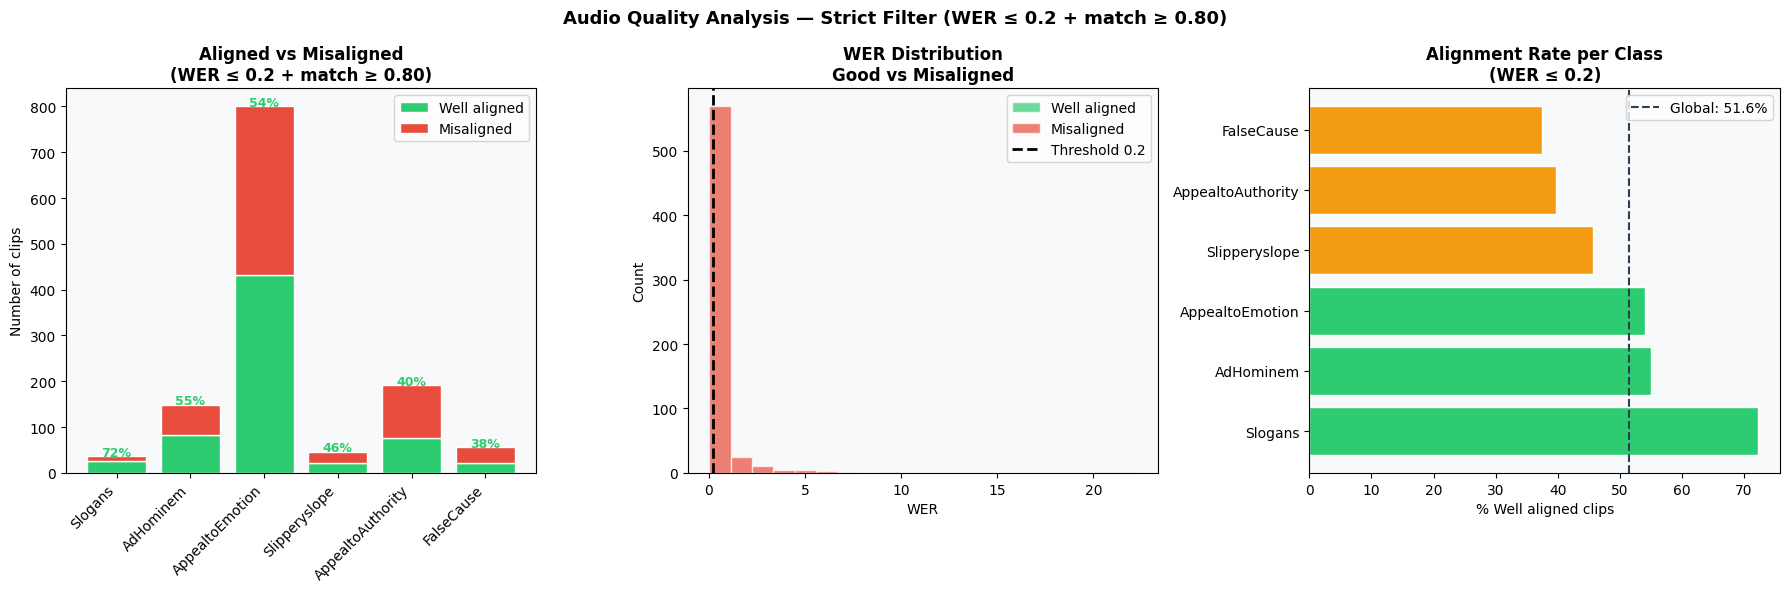

In [17]:
# Filtrage strict WER <= 0.2 pour l'analyse
mask_strict = (audit_df['match_score'] >= 0.80) & (audit_df['wer'] <= 0.2)

df_good = audit_df[mask_strict].copy()
df_bad  = audit_df[~mask_strict].copy()

print(f"Clips bien alignés  : {len(df_good)} ({100*len(df_good)/len(audit_df):.1f}%)")
print(f"Clips mal alignés   : {len(df_bad)}  ({100*len(df_bad)/len(audit_df):.1f}%)")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1 — Stacked bar par classe
class_stats = []
for cls, grp in audit_df.groupby('fallacy'):
    n_good = mask_strict[audit_df['fallacy'] == cls].sum()
    n_bad  = len(grp) - n_good
    class_stats.append({
        'class': cls,
        'n_good': n_good,
        'n_bad':  n_bad,
        'pct_good': 100 * n_good / len(grp)
    })
stats_df = pd.DataFrame(class_stats).sort_values('pct_good', ascending=False)

x = np.arange(len(stats_df))
axes[0].bar(x, stats_df['n_good'], color='#2ecc71', 
            label='Well aligned', edgecolor='white')
axes[0].bar(x, stats_df['n_bad'],  bottom=stats_df['n_good'],
            color='#e74c3c', label='Misaligned', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(stats_df['class'], rotation=45, ha='right')
axes[0].set_ylabel('Number of clips')
axes[0].set_title('Aligned vs Misaligned\n(WER ≤ 0.2 + match ≥ 0.80)', fontweight='bold')
axes[0].legend()
axes[0].set_facecolor('#f8f9fa')
for i, row in stats_df.reset_index().iterrows():
    axes[0].text(i, row['n_good'] + row['n_bad'] + 1,
                 f"{row['pct_good']:.0f}%",
                 ha='center', fontsize=9, color='#2ecc71', fontweight='bold')

# Plot 2 — WER distribution : good vs bad
axes[1].hist(df_good['wer'], bins=20, color='#2ecc71', 
             alpha=0.7, label='Well aligned', edgecolor='white')
axes[1].hist(df_bad['wer'],  bins=20, color='#e74c3c',  
             alpha=0.7, label='Misaligned',   edgecolor='white')
axes[1].axvline(x=0.2, color='black', linestyle='--', 
                linewidth=2, label='Threshold 0.2')
axes[1].set_xlabel('WER')
axes[1].set_ylabel('Count')
axes[1].set_title('WER Distribution\nGood vs Misaligned', fontweight='bold')
axes[1].legend()
axes[1].set_facecolor('#f8f9fa')

# Plot 3 — % bien aligné par classe
colors = ['#2ecc71' if p > 50 else '#f39c12' if p > 35 else '#e74c3c'
          for p in stats_df['pct_good']]
axes[2].barh(stats_df['class'], stats_df['pct_good'],
             color=colors, edgecolor='white')
axes[2].axvline(x=100*len(df_good)/len(audit_df), color='#2c3e50',
                linestyle='--', linewidth=1.5,
                label=f"Global: {100*len(df_good)/len(audit_df):.1f}%")
axes[2].set_xlabel('% Well aligned clips')
axes[2].set_title('Alignment Rate per Class\n(WER ≤ 0.2)', fontweight='bold')
axes[2].legend()
axes[2].set_facecolor('#f8f9fa')

fig.suptitle('Audio Quality Analysis — Strict Filter (WER ≤ 0.2 + match ≥ 0.80)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/alignment_strict_filter.png', 
            dpi=150, bbox_inches='tight')
plt.show()

In [18]:
print(audit_df['alignment_type'].value_counts())
print()
print(audit_df['alignment_type'].value_counts(normalize=True).mul(100).round(1))
print()
print("Par classe :")
for cls, grp in audit_df.groupby('fallacy'):
    counts = grp['alignment_type'].value_counts()
    print(f"\n  {cls}")
    for t, n in counts.items():
        print(f"    {t:<15} {n:>3} ({100*n/len(grp):.1f}%)")

alignment_type
Good            659
BadAlignment    407
TooShort        135
TooLong          77
Name: count, dtype: int64

alignment_type
Good            51.6
BadAlignment    31.8
TooShort        10.6
TooLong          6.0
Name: proportion, dtype: float64

Par classe :

  AdHominem
    Good             82 (55.0%)
    BadAlignment     49 (32.9%)
    TooShort         11 (7.4%)
    TooLong           7 (4.7%)

  AppealtoAuthority
    BadAlignment     80 (41.9%)
    Good             76 (39.8%)
    TooShort         24 (12.6%)
    TooLong          11 (5.8%)

  AppealtoEmotion
    Good            433 (54.1%)
    BadAlignment    223 (27.9%)
    TooShort         88 (11.0%)
    TooLong          56 (7.0%)

  FalseCause
    BadAlignment     30 (53.6%)
    Good             21 (37.5%)
    TooShort          4 (7.1%)
    TooLong           1 (1.8%)

  Slipperyslope
    Good             21 (45.7%)
    BadAlignment     19 (41.3%)
    TooShort          5 (10.9%)
    TooLong           1 (2.2%)

  Slogans
    

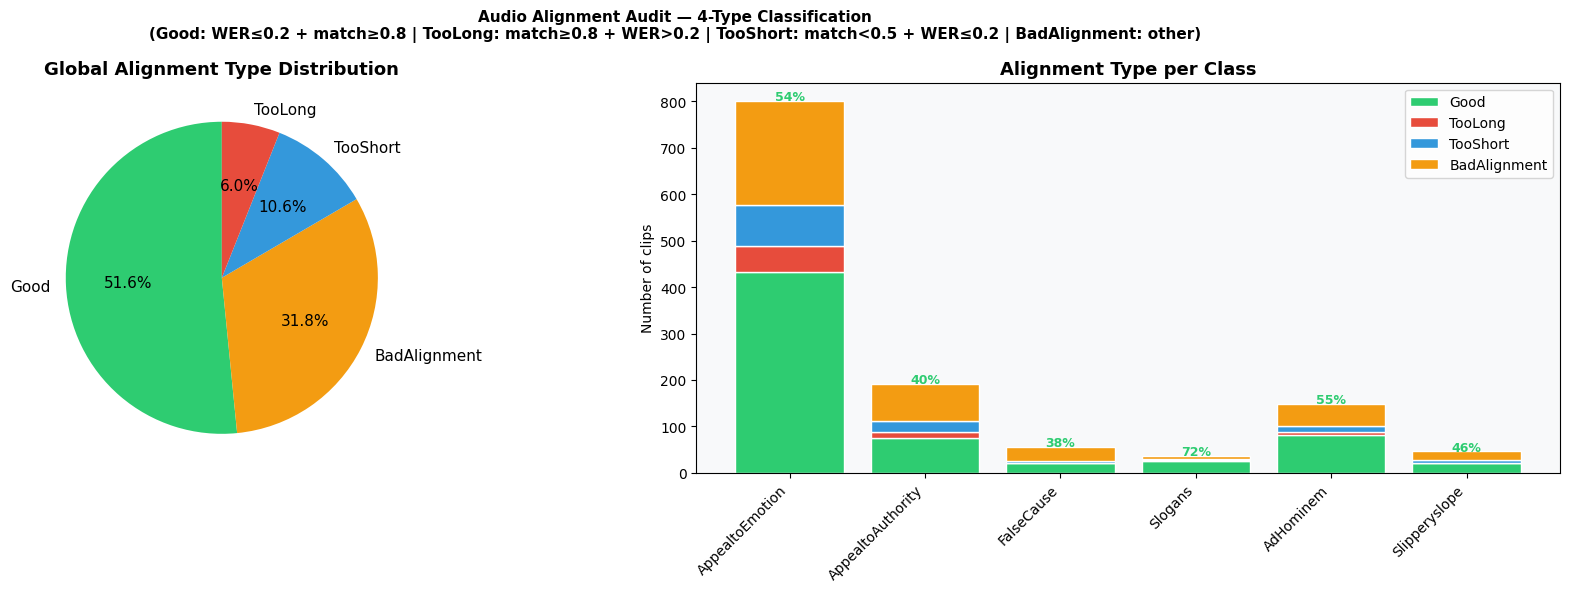

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Couleurs par type
type_colors = {
    'Good'         : '#2ecc71',
    'TooLong'      : '#e74c3c',
    'TooShort'     : '#3498db',
    'BadAlignment' : '#f39c12'
}

# Plot 1 — Distribution globale pie chart
counts = audit_df['alignment_type'].value_counts()
colors = [type_colors[t] for t in counts.index]

axes[0].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[0].set_title('Global Alignment Type Distribution', 
                  fontweight='bold', fontsize=13)

# Plot 2 — Stacked bar par classe
classes = audit_df['fallacy'].unique()
types   = ['Good', 'TooLong', 'TooShort', 'BadAlignment']

bottom = np.zeros(len(classes))
x = np.arange(len(classes))

for t in types:
    vals = [
        len(audit_df[(audit_df['fallacy'] == cls) & 
                     (audit_df['alignment_type'] == t)])
        for cls in classes
    ]
    axes[1].bar(x, vals, bottom=bottom, 
                color=type_colors[t], label=t, edgecolor='white')
    bottom += np.array(vals)

# Annotations % Good par classe
for i, cls in enumerate(classes):
    grp = audit_df[audit_df['fallacy'] == cls]
    pct_good = 100 * (grp['alignment_type'] == 'Good').mean()
    total = len(grp)
    axes[1].text(i, total + 2, f"{pct_good:.0f}%",
                 ha='center', fontsize=9, 
                 color='#2ecc71', fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels(classes, rotation=45, ha='right')
axes[1].set_ylabel('Number of clips')
axes[1].set_title('Alignment Type per Class', fontweight='bold', fontsize=13)
axes[1].legend(loc='upper right')
axes[1].set_facecolor('#f8f9fa')

fig.suptitle('Audio Alignment Audit — 4-Type Classification\n'
             '(Good: WER≤0.2 + match≥0.8 | TooLong: match≥0.8 + WER>0.2 | '
             'TooShort: match<0.5 + WER≤0.2 | BadAlignment: other)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/alignment_4types.png', 
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
bad = audit_df[audit_df['alignment_type'] == 'BadAlignment']
print(bad['fallacy'].value_counts())
print(bad[['wer', 'match_score']].describe())

fallacy
AppealtoEmotion      223
AppealtoAuthority     80
AdHominem             49
FalseCause            30
Slipperyslope         19
Slogans                6
Name: count, dtype: int64
              wer  match_score
count  407.000000   407.000000
mean     0.470763     0.400378
std      0.345291     0.247578
min      0.017241     0.000000
25%      0.240690     0.210550
50%      0.441860     0.437500
75%      0.674901     0.610434
max      3.947368     0.794872


In [22]:
pip install sentence_transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 9.7 MB/s eta 0:00:00ta 0:00:01

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [23]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Charger le modèle
print("Loading SentenceTransformer...")
sem_model = SentenceTransformer('all-MiniLM-L6-v2')

# Calculer la similarité sémantique pour tous les clips
print("Computing semantic similarity...")
ref_texts     = audit_df['ref_text'].tolist()
whisper_texts = audit_df['whisper_text'].tolist()

# Encoder en batch (plus rapide)
ref_embs     = sem_model.encode(ref_texts,     batch_size=64, show_progress_bar=True)
whisper_embs = sem_model.encode(whisper_texts, batch_size=64, show_progress_bar=True)

# Cosine similarity
from sklearn.metrics.pairwise import cosine_similarity
audit_df['semantic_sim'] = [
    cosine_similarity([ref_embs[i]], [whisper_embs[i]])[0][0]
    for i in range(len(audit_df))
]

print(f"\nSemantic similarity global :")
print(f"  Mean   : {audit_df['semantic_sim'].mean():.3f}")
print(f"  Median : {audit_df['semantic_sim'].median():.3f}")
print(f"  < 0.5  : {(audit_df['semantic_sim'] < 0.5).sum()} clips ({100*(audit_df['semantic_sim'] < 0.5).mean():.1f}%)")
print(f"  > 0.8  : {(audit_df['semantic_sim'] > 0.8).sum()} clips ({100*(audit_df['semantic_sim'] > 0.8).mean():.1f}%)")

print(f"\nPar classe :")
for cls, grp in audit_df.groupby('fallacy'):
    print(f"  {cls:<25} mean={grp['semantic_sim'].mean():.3f}  median={grp['semantic_sim'].median():.3f}")

/workspace/patootie_code/mm_argfallacy/mmarg_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading SentenceTransformer...
Computing semantic similarity...


Batches: 100%|██████████| 20/20 [00:00<00:00, 136.65it/s]



Semantic similarity global :
  Mean   : 0.910
  Median : 0.983
  < 0.5  : 40 clips (3.1%)
  > 0.8  : 1061 clips (83.0%)

Par classe :
  AdHominem                 mean=0.899  median=0.976
  AppealtoAuthority         mean=0.875  median=0.966
  AppealtoEmotion           mean=0.917  median=0.987
  FalseCause                mean=0.910  median=0.952
  Slipperyslope             mean=0.922  median=0.978
  Slogans                   mean=0.958  median=0.996


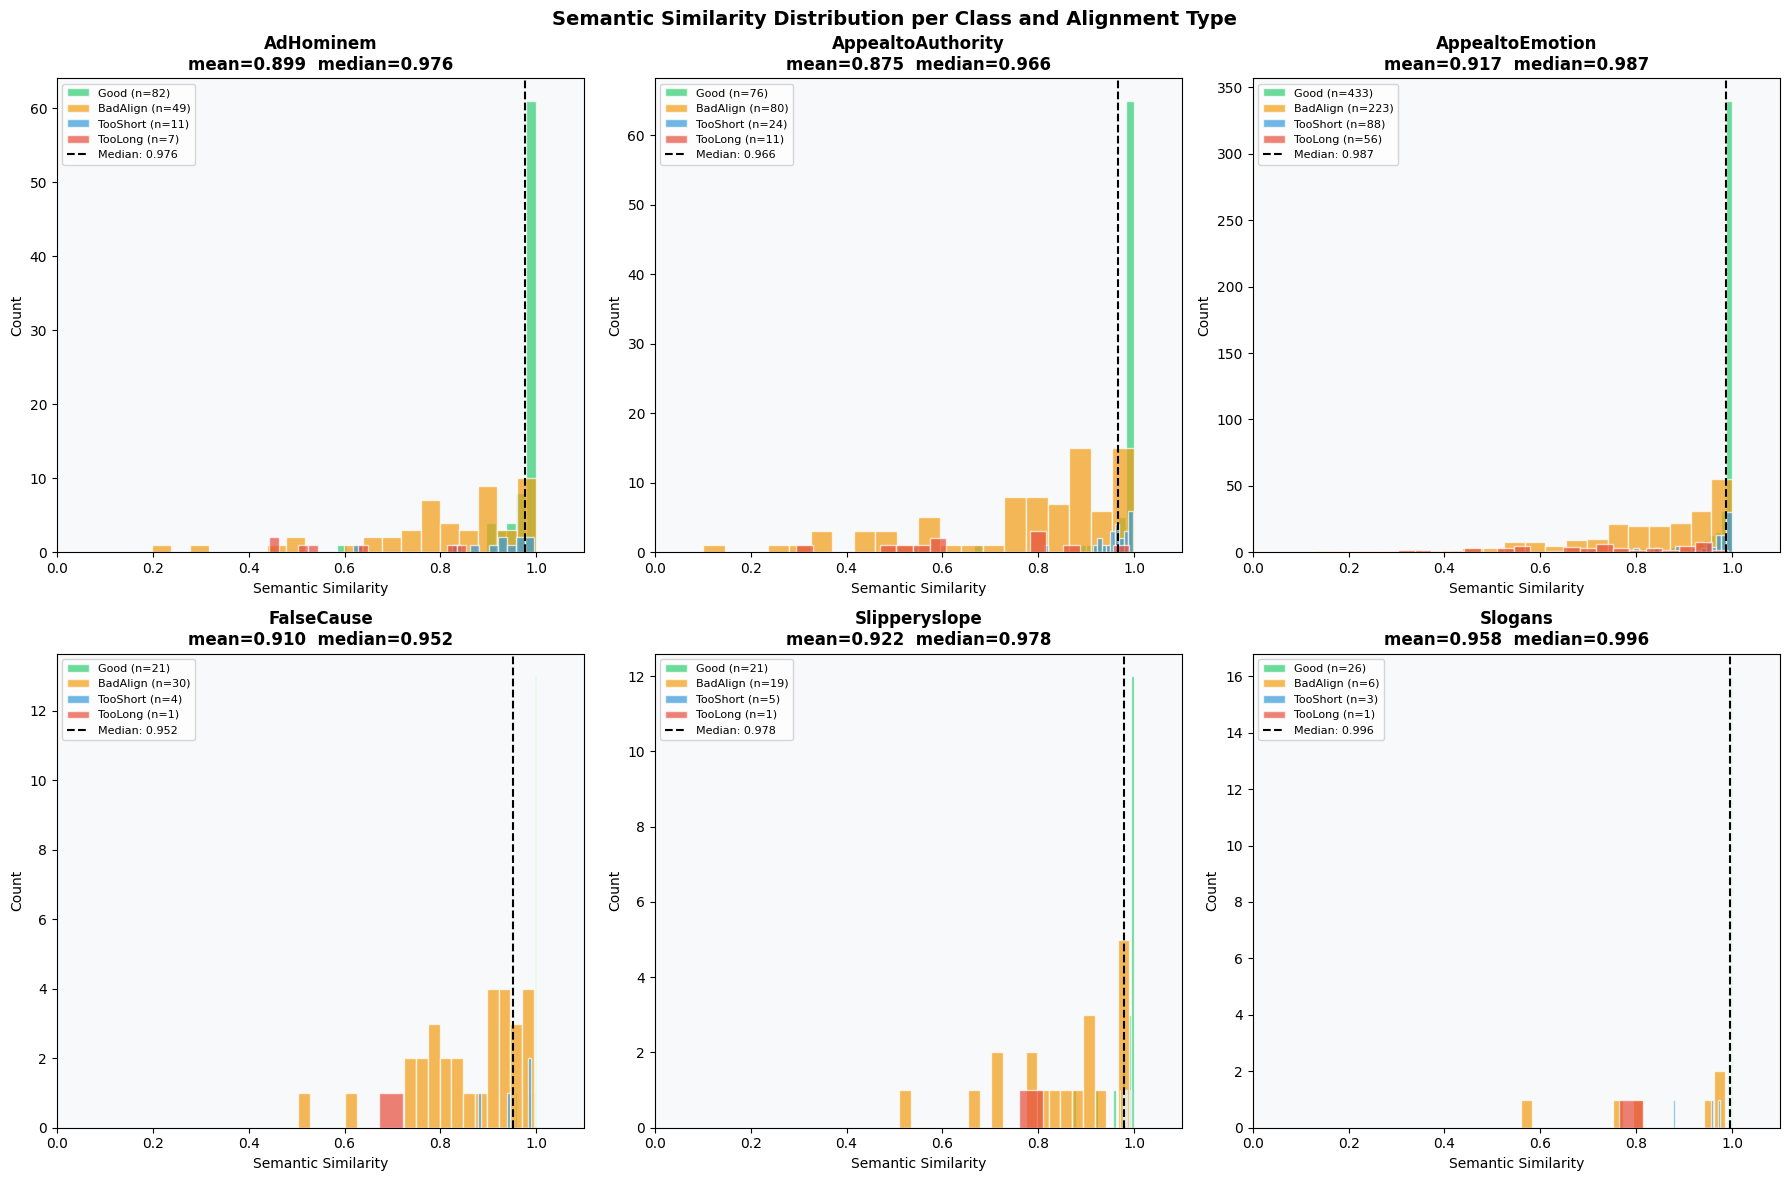

Semantic similarity par classe et alignment_type :

AdHominem
  BadAlignment    n= 49  mean=0.806  median=0.839  < 0.5: 4
  Good            n= 82  mean=0.979  median=1.000  < 0.5: 0
  TooLong         n=  7  mean=0.612  median=0.542  < 0.5: 2
  TooShort        n= 11  mean=0.905  median=0.933  < 0.5: 0

AppealtoAuthority
  BadAlignment    n= 80  mean=0.772  median=0.832  < 0.5: 11
  Good            n= 76  mean=0.986  median=0.997  < 0.5: 0
  TooLong         n= 11  mean=0.661  median=0.582  < 0.5: 2
  TooShort        n= 24  mean=0.961  median=0.963  < 0.5: 0

AppealtoEmotion
  BadAlignment    n=223  mean=0.820  median=0.862  < 0.5: 12
  Good            n=433  mean=0.987  median=1.000  < 0.5: 0
  TooLong         n= 56  mean=0.711  median=0.733  < 0.5: 9
  TooShort        n= 88  mean=0.953  median=0.977  < 0.5: 0

FalseCause
  BadAlignment    n= 30  mean=0.858  median=0.900  < 0.5: 0
  Good            n= 21  mean=0.990  median=1.000  < 0.5: 0
  TooLong         n=  1  mean=0.672  median=0.67

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

classes = sorted(audit_df['fallacy'].unique())

for i, cls in enumerate(classes):
    grp = audit_df[audit_df['fallacy'] == cls]
    
    # Séparer par alignment_type
    good = grp[grp['alignment_type'] == 'Good']['semantic_sim']
    bad  = grp[grp['alignment_type'] == 'BadAlignment']['semantic_sim']
    short = grp[grp['alignment_type'] == 'TooShort']['semantic_sim']
    long_ = grp[grp['alignment_type'] == 'TooLong']['semantic_sim']
    
    # Plot histogram par type
    if len(good) > 0:
        axes[i].hist(good,  bins=20, alpha=0.7, color='#2ecc71', 
                     label=f'Good (n={len(good)})',     edgecolor='white')
    if len(bad) > 0:
        axes[i].hist(bad,   bins=20, alpha=0.7, color='#f39c12', 
                     label=f'BadAlign (n={len(bad)})',  edgecolor='white')
    if len(short) > 0:
        axes[i].hist(short, bins=20, alpha=0.7, color='#3498db', 
                     label=f'TooShort (n={len(short)})', edgecolor='white')
    if len(long_) > 0:
        axes[i].hist(long_, bins=20, alpha=0.7, color='#e74c3c', 
                     label=f'TooLong (n={len(long_)})', edgecolor='white')
    
    # Ligne médiane globale
    axes[i].axvline(x=grp['semantic_sim'].median(), color='black', 
                    linestyle='--', linewidth=1.5,
                    label=f"Median: {grp['semantic_sim'].median():.3f}")
    
    axes[i].set_title(f'{cls}\nmean={grp["semantic_sim"].mean():.3f}  '
                      f'median={grp["semantic_sim"].median():.3f}',
                      fontweight='bold')
    axes[i].set_xlabel('Semantic Similarity')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)
    axes[i].set_facecolor('#f8f9fa')
    axes[i].set_xlim(0, 1.1)

fig.suptitle('Semantic Similarity Distribution per Class and Alignment Type',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/semantic_sim_per_class.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# Stats détaillées
print("Semantic similarity par classe et alignment_type :\n")
for cls, grp in audit_df.groupby('fallacy'):
    print(f"{cls}")
    for t, subgrp in grp.groupby('alignment_type'):
        print(f"  {t:<15} n={len(subgrp):>3}  "
              f"mean={subgrp['semantic_sim'].mean():.3f}  "
              f"median={subgrp['semantic_sim'].median():.3f}  "
              f"< 0.5: {(subgrp['semantic_sim'] < 0.5).sum()}")
    print()

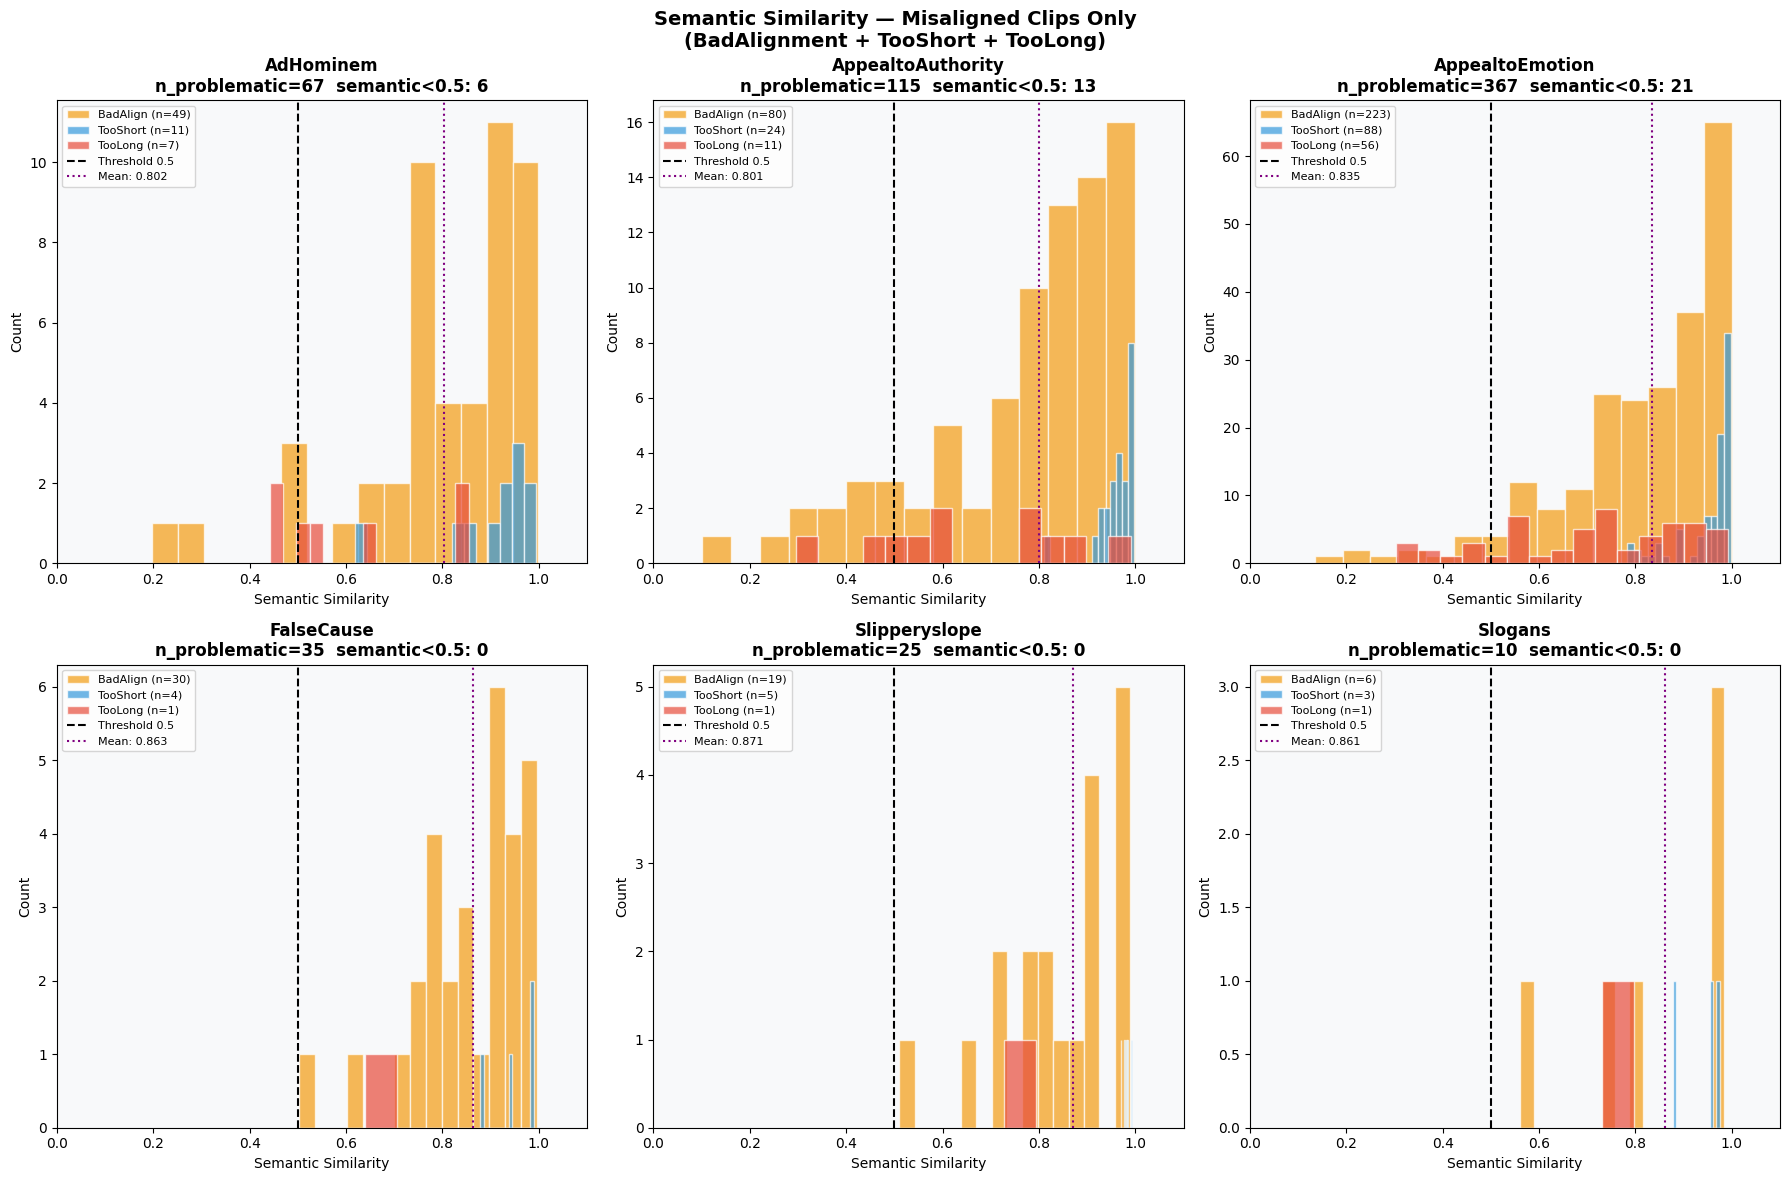

Clips problématiques (semantic < 0.5) par classe :

  AdHominem                 problematic= 67  semantic<0.5:  6  (4.0% of class)
  AppealtoAuthority         problematic=115  semantic<0.5: 13  (6.8% of class)
  AppealtoEmotion           problematic=367  semantic<0.5: 21  (2.6% of class)
  FalseCause                problematic= 35  semantic<0.5:  0  (0.0% of class)
  Slipperyslope             problematic= 25  semantic<0.5:  0  (0.0% of class)
  Slogans                   problematic= 10  semantic<0.5:  0  (0.0% of class)


In [28]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

classes = sorted(audit_df['fallacy'].unique())

for i, cls in enumerate(classes):
    grp = audit_df[audit_df['fallacy'] == cls]
    
    # Exclure les Good — on veut voir uniquement les problématiques
    bad   = grp[grp['alignment_type'] == 'BadAlignment']['semantic_sim']
    short = grp[grp['alignment_type'] == 'TooShort']['semantic_sim']
    long_ = grp[grp['alignment_type'] == 'TooLong']['semantic_sim']
    
    if len(bad) > 0:
        axes[i].hist(bad,   bins=15, alpha=0.7, color='#f39c12',
                     label=f'BadAlign (n={len(bad)})',   edgecolor='white')
    if len(short) > 0:
        axes[i].hist(short, bins=15, alpha=0.7, color='#3498db',
                     label=f'TooShort (n={len(short)})', edgecolor='white')
    if len(long_) > 0:
        axes[i].hist(long_, bins=15, alpha=0.7, color='#e74c3c',
                     label=f'TooLong (n={len(long_)})',  edgecolor='white')
    
    # Ligne seuil sémantique
    axes[i].axvline(x=0.5, color='black', linestyle='--', 
                    linewidth=1.5, label='Threshold 0.5')
    
    # Stats sur les clips problématiques uniquement
    problematic = grp[grp['alignment_type'] != 'Good']['semantic_sim']
    if len(problematic) > 0:
        axes[i].axvline(x=problematic.mean(), color='purple', 
                        linestyle=':', linewidth=1.5,
                        label=f'Mean: {problematic.mean():.3f}')
    
    n_dangerous = (problematic < 0.5).sum() if len(problematic) > 0 else 0
    
    axes[i].set_title(f'{cls}\n'
                      f'n_problematic={len(problematic)}  '
                      f'semantic<0.5: {n_dangerous}',
                      fontweight='bold')
    axes[i].set_xlabel('Semantic Similarity')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)
    axes[i].set_facecolor('#f8f9fa')
    axes[i].set_xlim(0, 1.1)

fig.suptitle('Semantic Similarity — Misaligned Clips Only\n'
             '(BadAlignment + TooShort + TooLong)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/semantic_sim_misaligned_only.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Stats détaillées sur les clips problématiques
print("Clips problématiques (semantic < 0.5) par classe :\n")
for cls, grp in audit_df.groupby('fallacy'):
    problematic = grp[grp['alignment_type'] != 'Good']
    dangerous   = problematic[problematic['semantic_sim'] < 0.5]
    print(f"  {cls:<25} problematic={len(problematic):>3}  "
          f"semantic<0.5: {len(dangerous):>2}  "
          f"({100*len(dangerous)/len(grp):.1f}% of class)")

/tmp/ipykernel_1175091/3020160163.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1175091/3020160163.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1175091/3020160163.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1175091/3020160163.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1175091/3020160163.py:19: Fut

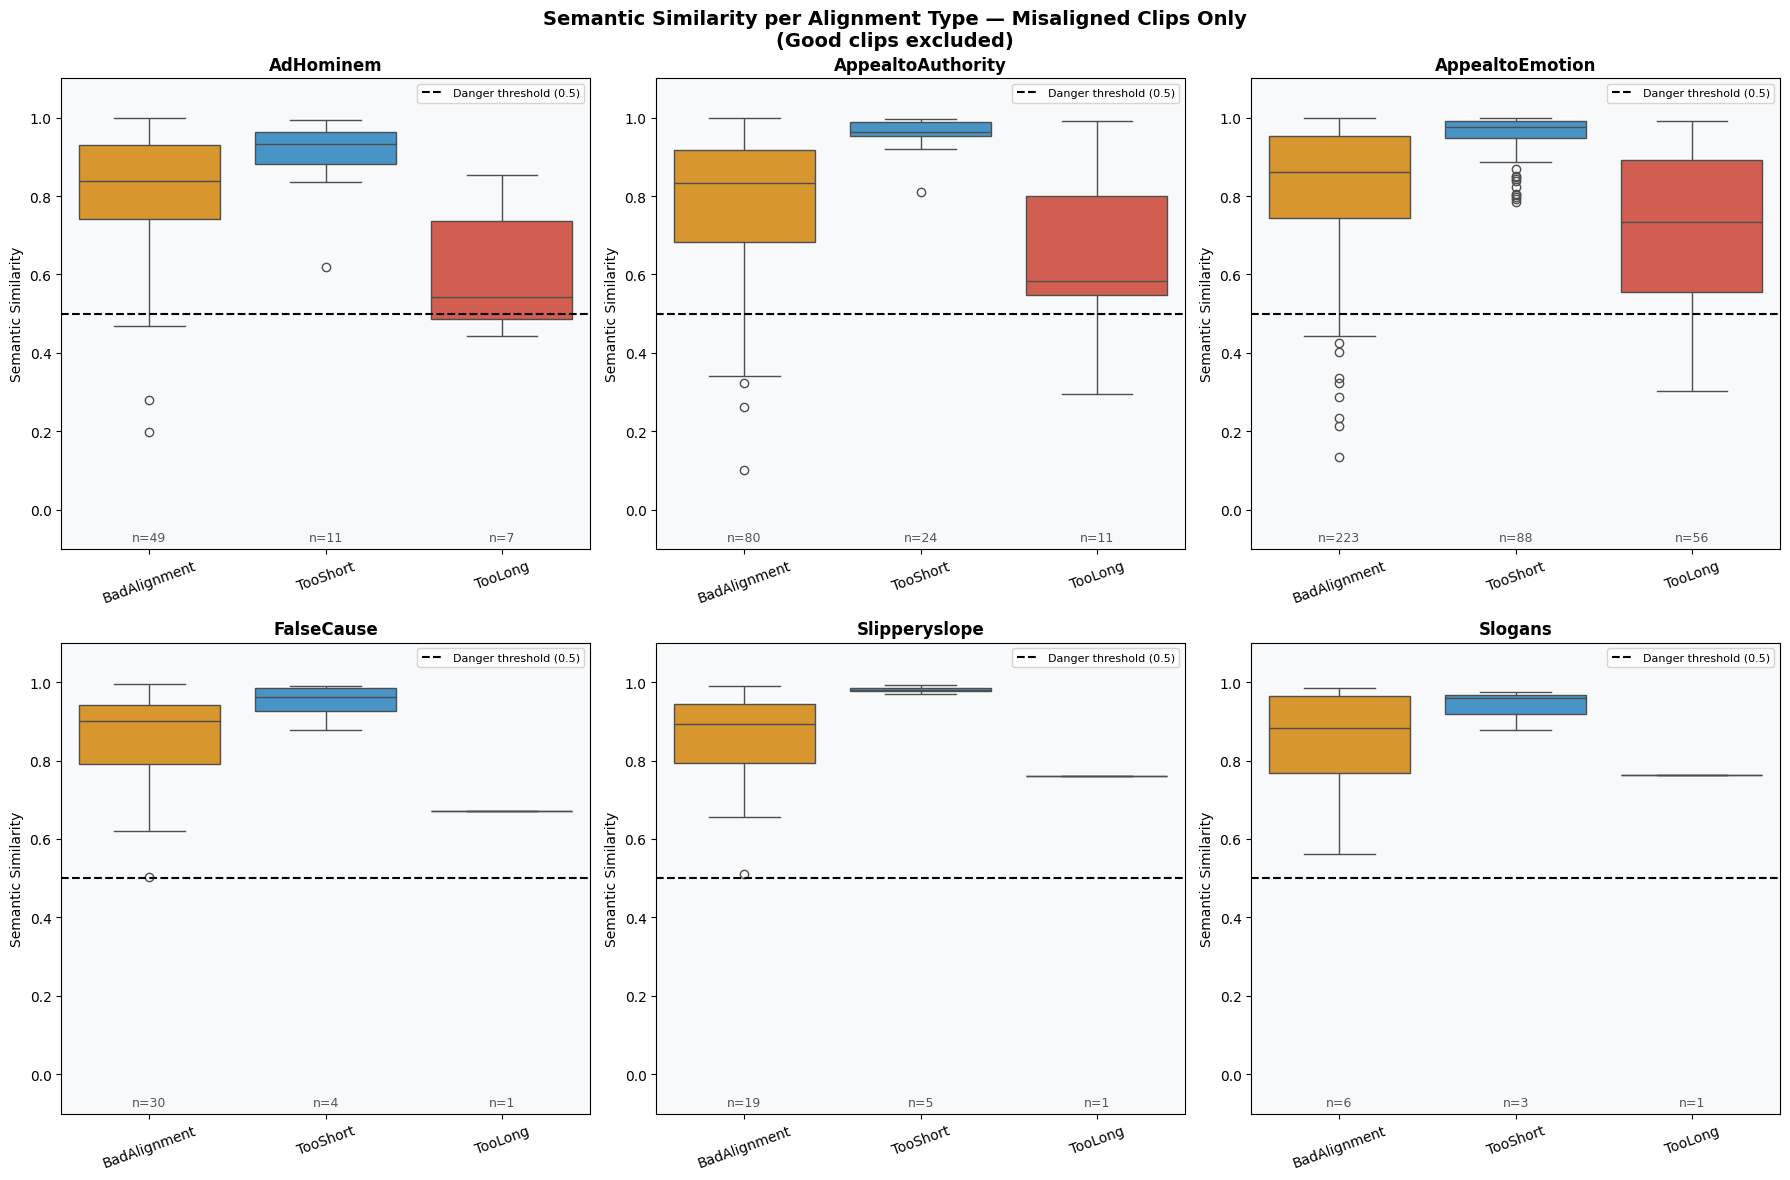

In [27]:
import seaborn as sns

# Filtrer uniquement les clips problématiques
df_prob = audit_df[audit_df['alignment_type'] != 'Good'].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

classes = sorted(df_prob['fallacy'].unique())
type_colors = {
    'BadAlignment' : '#f39c12',
    'TooShort'     : '#3498db',
    'TooLong'      : '#e74c3c'
}

for i, cls in enumerate(classes):
    grp = df_prob[df_prob['fallacy'] == cls]
    
    sns.boxplot(
        data=grp,
        x='alignment_type',
        y='semantic_sim',
        palette=type_colors,
        order=['BadAlignment', 'TooShort', 'TooLong'],
        ax=axes[i]
    )
    
    # Ligne seuil dangereux
    axes[i].axhline(y=0.5, color='black', linestyle='--',
                    linewidth=1.5, label='Danger threshold (0.5)')
    
    # Annotations n par type
    for j, t in enumerate(['BadAlignment', 'TooShort', 'TooLong']):
        n = len(grp[grp['alignment_type'] == t])
        axes[i].text(j, -0.08, f'n={n}', ha='center', fontsize=9, color='#555')
    
    axes[i].set_title(f'{cls}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Semantic Similarity')
    axes[i].set_ylim(-0.1, 1.1)
    axes[i].legend(fontsize=8)
    axes[i].set_facecolor('#f8f9fa')
    axes[i].tick_params(axis='x', rotation=20)

fig.suptitle('Semantic Similarity per Alignment Type — Misaligned Clips Only\n'
             '(Good clips excluded)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/semantic_sim_boxplot.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Analyse context dialogue 

Building AFC Context: 100%|██████████| 1278/1278 [00:00<00:00, 2619.84it/s]


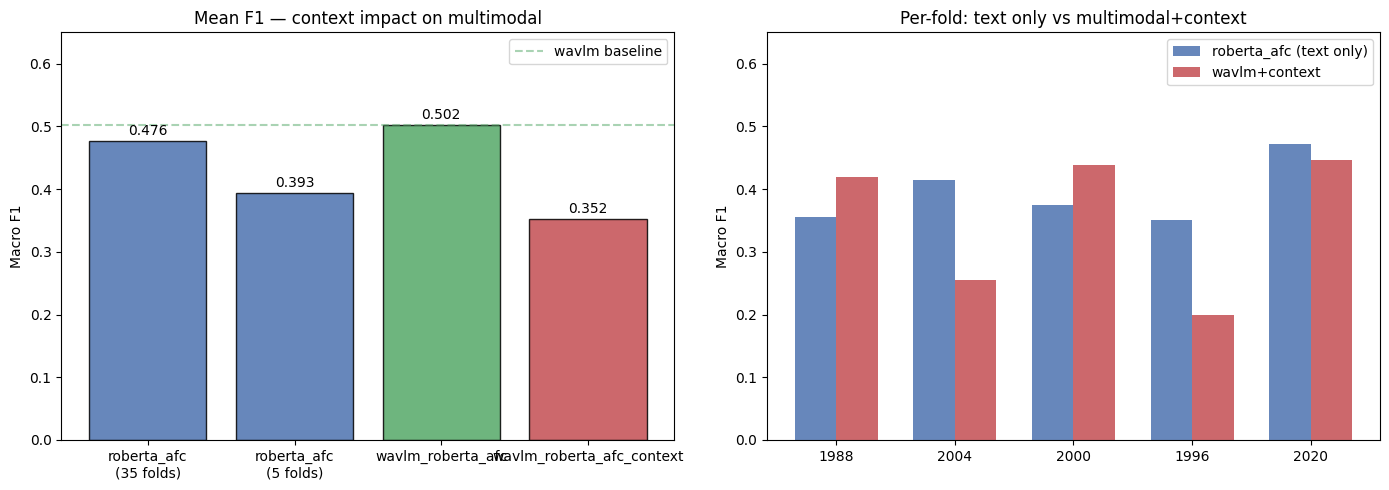


=== Summary ===
roberta_afc (35 folds) : 0.4764
roberta_afc ( 5 folds) : 0.3934
wavlm_roberta_afc      : 0.5022
wavlm_roberta_afc_ctx  : 0.3521

Delta (multimodal vs +context): +0.1502

Per-fold breakdown:
  13_1988: roberta=0.355  wavlm+ctx=0.420  Δ=+0.065
  31_2004: roberta=0.414  wavlm+ctx=0.255  Δ=-0.159
  25_2000: roberta=0.375  wavlm+ctx=0.439  Δ=+0.064
  22_1996: roberta=0.351  wavlm+ctx=0.200  Δ=-0.151
  46_2020: roberta=0.472  wavlm+ctx=0.447  Δ=-0.025


In [37]:
import json
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')

from src.configs.fold_selection import MULTIMODAL_TEST_DIALOGUES
from src.experiments.mmused_text import make_mmused_fallacy_loader
from src.utils.splits import infer_held_out_dialogue_id, sort_ldocv_splits

# --- roberta_afc scores for the same 5 folds ---
loader = make_mmused_fallacy_loader('afc')
splits = list(loader.get_splits('mancini-et-al-2024'))
splits = sort_ldocv_splits(loader, splits)
fold_dialogues = [infer_held_out_dialogue_id(loader, sp) for sp in splits]

d = json.load(open('../results/results.json'))
roberta_scores_5 = {did: s for did, s in zip(fold_dialogues, d['roberta_afc']['scores'])
                    if did in MULTIMODAL_TEST_DIALOGUES}

# --- all scores per experiment ---
exps = {
    'roberta_afc\n(35 folds)':        (d['roberta_afc']['mean'],   None),
    'roberta_afc\n(5 folds)':         (np.mean(list(roberta_scores_5.values())), list(roberta_scores_5.values())),
    'wavlm_roberta_afc':              (d['wavlm_roberta_afc']['mean'],         d['wavlm_roberta_afc']['scores']),
    'wavlm_roberta_afc_context':      (d['wavlm_roberta_afc_context']['mean'],  d['wavlm_roberta_afc_context']['scores']),
}

# --- per-fold breakdown: roberta vs roberta+context ---
dialogues = MULTIMODAL_TEST_DIALOGUES
roberta_5  = [roberta_scores_5[d] for d in dialogues]
ctx_scores = d['wavlm_roberta_afc_context']['scores']  # same fold order

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: mean F1 comparison
names  = list(exps.keys())
means  = [v[0] for v in exps.values()]
colors = ['#4C72B0', '#4C72B0', '#55A868', '#C44E52']
bars = axes[0].bar(names, means, color=colors, alpha=0.85, edgecolor='black')
for bar, val in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)
axes[0].set_ylim(0, 0.65)
axes[0].set_ylabel('Macro F1')
axes[0].set_title('Mean F1 — context impact on multimodal')
axes[0].axhline(0.502, color='#55A868', linestyle='--', alpha=0.5, label='wavlm baseline')
axes[0].legend()

# Plot 2: per-fold delta (roberta_5 vs wavlm+context)
x = np.arange(len(dialogues))
w = 0.35
axes[1].bar(x - w/2, roberta_5,  w, label='roberta_afc (text only)', color='#4C72B0', alpha=0.85)
axes[1].bar(x + w/2, ctx_scores, w, label='wavlm+context',           color='#C44E52', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels([d.split('_')[1] for d in dialogues])
axes[1].set_ylabel('Macro F1')
axes[1].set_title('Per-fold: text only vs multimodal+context')
axes[1].legend()
axes[1].set_ylim(0, 0.65)

plt.tight_layout()
plt.savefig('../results/context_analysis.png', dpi=150)
plt.show()

print("\n=== Summary ===")
print(f"roberta_afc (35 folds) : {d['roberta_afc']['mean']:.4f}")
print(f"roberta_afc ( 5 folds) : {np.mean(roberta_5):.4f}")
print(f"wavlm_roberta_afc      : {d['wavlm_roberta_afc']['mean']:.4f}")
print(f"wavlm_roberta_afc_ctx  : {d['wavlm_roberta_afc_context']['mean']:.4f}")
print(f"\nDelta (multimodal vs +context): {d['wavlm_roberta_afc']['mean'] - d['wavlm_roberta_afc_context']['mean']:+.4f}")
print(f"\nPer-fold breakdown:")
for did, r, c in zip(dialogues, roberta_5, ctx_scores):
    print(f"  {did}: roberta={r:.3f}  wavlm+ctx={c:.3f}  Δ={c-r:+.3f}")
